<font size = "4">

**Knight's Tour Problem**

- This puzzle starts with a chess board containing a single chess piece, the knight.

- The object is to find a sequence of legal moves that allow the knight to visit every square on the board exactly once. Each sequence is called a *tour*.

- An upper bound on the number of possible legal tours for an $8\times 8$ chessboard is $1.305 \times 10^{35}$, but there are even more legal sequences that fail to complete a tour.

- Our approach to solving this problem:

    - Represent the legal moves of a knight on a chessboard as a graph.

    - Use a graph algorithm (depth-first search) to find a path of length $\textrm{rows} \times (\textrm{columns} - 1)$ where every vertex on the graph is visited exactly once.

<font size = "4">

**Building the Knight's Tour Graph**

- Each square on the chessboard can be represented as a vertex in the graph, and each legal move can be represented as an edge.

- Here is a representation of the legal moves a knight starting in the center of a $5 \times 5$ chessboard can take. This is just a **subgraph** of the full graph.

<div style="text-align: center;">
  <img src="files/knightmoves.png" alt="Centered image" width = "500">
  <br>
  <br>
  <figcaption>
  <font size = "1"> Miller, Randum, Yasinovskyy (Problem Solving with Algorithms and Data Structures using Python)</figcaption>
</div>

<br>

<font size = "4">

- First, we'll need a function to determine the legal moves on an $n\times n$ chessboard starting from an arbitrary position:

In [1]:
def gen_legal_moves(row, col, board_size):
    new_moves = []
    move_offsets = [
        (-1, -2),  # left-down-down
        (-1, 2),   # left-up-up
        (-2, -1),  # left-left-down
        (-2, 1),   # left-left-up
        (1, -2),   # right-down-down
        (1, 2),    # right-up-up
        (2, -1),   # right-right-down
        (2, 1),    # right-right-up
    ]
    for r_off, c_off in move_offsets:
        if 0 <= row + r_off < board_size and 0 <= col + c_off < board_size:
            new_moves.append((row + r_off, col + c_off))
    return new_moves

<font size = "4">

- Now, we right a function that creates a graph representation of an $n\times n$ chess board:

In [2]:
from datasci531 import Graph

def knight_graph(board_size):
    kt_graph = Graph()
    for row in range(board_size):
        for col in range(board_size):
            node_id = row * board_size + col
            new_positions = gen_legal_moves(row, col, board_size)
            for row2, col2 in new_positions:
                other_node_id = row2 * board_size + col2
                kt_graph.add_edge(node_id, other_node_id)
    return kt_graph

In [3]:
G = knight_graph(8)

<font size = "4">

- Below is the graph representation of legal moves for an $8 \times 8$ chessboard.

<div style="text-align: center;">
  <img src="files/bigknight.png" alt="Centered image" width = "500">
  <br>
  <br>
  <figcaption>
  <font size = "1"> Miller, Randum, Yasinovskyy (Problem Solving with Algorithms and Data Structures using Python)</figcaption>
</div>

<br>



<font size = "4">

- If the graph were fully connected, there would be 4,032 edges (2 edges between each pair of vertices). But there are only 336 edges:

In [4]:
num_edges = 0
for v in G.vertices.values():
    num_edges += len(v.get_neighbors())

print(num_edges)

336


<font size = "4">

- So if we used an adjacency matrix to represent the graph, only $\approx 8.3$ percent of the entries would be non-zero. Thus, the graph is quite sparse, and we are better off with the adjacency list representation (or a compressed storage representation of the adjacency matrix).

- **Bonus:** Here is how we can represent the adjacency matrix in **CSR (Compressed Sparse Row)** format:

In [5]:
data = []
indices = []
rowptr = [0] * (len(G.vertices) + 1)
shape = (64, 64)

for i in sorted(list(G.vertices.keys())):
    rowptr[i+1] = rowptr[i]
    for j in G.get_vertex(i).get_neighbors():
        data.append(1)
        indices.append(j.key)
        rowptr[i+1] += 1

print("Total number of stored values for weighted graph:", len(data) + len(indices) + len(rowptr) + len(shape))
print("Total number of stored values in 64x64 matrix:", 64*64)
print()
print("Total number of stored values for unweighted graph:", len(indices) + len(rowptr) + len(shape))

Total number of stored values for weighted graph: 739
Total number of stored values in 64x64 matrix: 4096

Total number of stored values for unweighted graph: 403


In [6]:
vertex = 43
print(f"Vertex {vertex} is connected to:")
start = rowptr[vertex]
end = rowptr[vertex + 1]
for j in indices[start:end]:
    print(f"   Vertex {j}")

Vertex 43 is connected to:
   Vertex 33
   Vertex 37
   Vertex 26
   Vertex 28
   Vertex 49
   Vertex 53
   Vertex 58
   Vertex 60


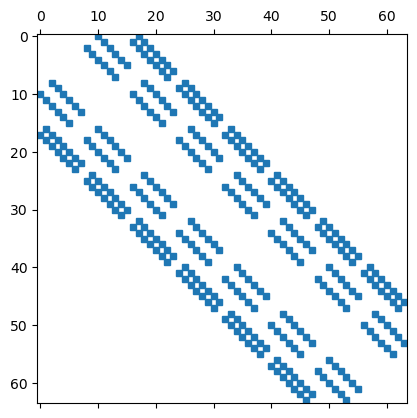

In [7]:
from scipy.sparse import csr_matrix
import matplotlib.pyplot as plt
A = csr_matrix((data, indices, rowptr), shape = shape)
plt.spy(A,markersize = 5)
plt.show()

<font size = "4">

**Implementing Knight's Tour**

- We will use **Depth-First Search (DFS)** to solve the problem. 

- Whereas Breadth-First Search builds a tree one level at a time, a Depth-First Search creates a tree by constructing one branch of the tree as deeply as possible.

- To solve the knight's tour problem, our algorithm will explicitly forbid a vertex from being visited more than once. The general DFS algorithm does not enforce this constraint.

- Our goal is to find a path passing through 64 vertices on the chessboard, traveling along 63 edges. (For a general $n = k^2$ board, we would look for a path through $k$ vertices and $k-1$ edges )

- When the algorithm finds a dead end (no more legal moves to unexplored vertices), it backs up the tree to the next deepest vertex that allows for a legal move.

In [ ]:
def knight_tour(path, vertex, num_nodes):
    vertex.color = "gray"
    path.append(vertex)
    if len(path) < num_nodes:
        neighbors = list(vertex.get_neighbors())
        i = 0
        done = False
        while i < len(neighbors) and not done:
            if neighbors[i].color == "white":
                done = knight_tour(path, neighbors[i], num_nodes)
            i = i + 1
        if not done: # prepare to backtrack
            path.pop()
            vertex.color = "white"
    else:
        done = True
    return done


In [ ]:
G = knight_graph(8)
path = []
knight_tour(path, G.get_vertex(0), 64) # took around 10.2 seconds the first time


In [ ]:
G = knight_graph(5)
path = []
knight_tour(path, G.get_vertex(0), 25) 

In [ ]:
path

In [ ]:
G = knight_graph(4)
path = []
knight_tour(path, G.get_vertex(0), 16) # took around 10.2 seconds the first time

<font size = "4">

**Analysis of Knight's Tour**

- The solution of the knight's tour problem we implemented has exponential cost! Specifically, the running time is $\mathcal{O}(k^N)$ where $N$ is the number of squares on the board, and $k$ is a small constant.

- To help understand, here is a portion of the search tree for an $8\times 8$ board

<div style="text-align: center;">
  <img src="files/8arrayTree.png" alt="Centered image" width = "500">
  <br>
  <br>
  <figcaption>Portion of Search Tree for an 8x8 board<br>
  <font size = "1"> Miller, Randum, Yasinovskyy (Problem Solving with Algorithms and Data Structures using Python)</figcaption>
</div>

<br>

<font size = "4">

<div style="text-align: center;">
  <img src="files/moveCount.png" alt="Centered image" width = "300">
  <br>
  <br>
  <figcaption>Number of possible moves for each square<br>
  <font size = "1"> Miller, Randum, Yasinovskyy (Problem Solving with Algorithms and Data Structures using Python)</figcaption>
</div>

<font size = "4">

- The root of the tree represents the starting point of the search.

- The algorithm generates and checks each of the possible moves the knight can make.

- The number of possible moves depends on the position of the knight on the board. At the corners, there are only two legal moves, in the middle of the board there are eight.

- The number of nodes in a binary tree of height $N$ is $2^{N+1} - 1$ (counting the root node). If the nodes can have up to 8 children, the number of nodes is much larger.

- The cost of the algorithm is related to $k^{N+1} - 1$ where $k$ is the average branching factor for the board (on average, how many legal moves there are.)

- For an $8\times 8$ chessboard, we have $k = 5.25$ and there are $1.3 \times 10^{46}$ nodes in the search tree.

<font size ="4">

- We can speed up the solution by using a *heuristic*.

- Choosing a node with a larger amount of unexplored children means we tend to search toward the middle of the board first.

- Then the knight can move across the board, getting "stranded" and cannot reach the other side of the board via unvisited squares.

- So starting from a given vertex, we should first search paths starting with children who have the fewest possible unexplored children themselves. 

- This means we will explore the hard-to-reach corners first, and only uses the middle squares when necessary.

- This is called Warnsdorf's rule, described by H.C. von Warnsdorf in 1823. It speeds up the computation considerably:


In [ ]:
def order_by_avail(vertex):
    res_list = []
    for v in vertex.get_neighbors():
        if v.color == "white":
            c = 0
            for w in v.get_neighbors():
                if w.color == "white":
                    c = c + 1
            res_list.append((c, v))
    res_list.sort(key=lambda x: x[0])
    return [y[1] for y in res_list]

In [ ]:
G = knight_graph(8)

v = G.get_vertex(18)
v.get_neighbors()

In [ ]:
order_by_avail(v)

In [ ]:
def knight_tour_heuristic(path, vertex, num_nodes):
    vertex.color = "gray"
    path.append(vertex)
    if len(path) < num_nodes:
        neighbors = order_by_avail(vertex) # changed this line
        i = 0
        done = False
        while i < len(neighbors) and not done:
            if neighbors[i].color == "white":
                done = knight_tour_heuristic(path, neighbors[i], num_nodes)
            i = i + 1
        if not done: # prepare to backtrack
            path.pop()
            vertex.color = "white"
    else:
        done = True
    return done

In [ ]:
G = knight_graph(8)
path = []
knight_tour_heuristic(path, G.get_vertex(0), 64) # took around "0.0" seconds the first time
